<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Unsurpervised_Learning_Visualization_PCA_%26_tSNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unsupervised Learning - Visualization Patient Populations with Dimensionality Reduction (PCA & t-SNE)


## Overview
Healthcare datasets often contain many variables describing patients, such as
lab values, utilization measures, and condition indicators.
While these variables are meaningful individually, they are difficult
to reason about collectively.

Dimensionality reduction helps **compress complex patient information**
into a small number of dimensions that can be visualized.
These visualizations support clinical intuition, hypothesis generation,
and communication with non-technical stakeholders.

The goal of this work is **understanding and interpretation**, not mathematical depth.

## Objectives
- Prepare patient-level features for analysis and visualization.
- Apply two common dimensionality reduction techniques to clinical data.
  1. Principal component analysis (PCA)
  2. t-distributed stochastic neighbor embedding (t-SNE)
- Visualize patient populations in 2D space.
Identify and interpret potential clinical subgroups.

## The Dataset
The dataset contains synthetic, de-identified patient-level clinical features used for exploratory visualization of healthcare data.


## 0. Setup

In [25]:
import pandas as pd


# Import tools for scaling and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Import matplotlib for plotting
import matplotlib.pyplot as plt


# Load a synthetic patient-level feature dataset

patient_features = pd.read_csv("https://machine-learning-for-healthcare-applications-f276df.gitlab.io/labs/lab3/patient_features.csv")

# Display the dataset
patient_features.head(10)

,avg_glucose,encounter_count,has_diabetes,has_hypertension
0,135.9,2,1,0
1,122.0,1,1,0
2,139.2,2,1,0
3,158.5,1,0,0
4,119.8,4,0,0
5,119.8,5,1,0
6,159.7,1,0,1
7,141.9,5,1,1
8,114.7,3,1,0
9,136.9,2,1,0


#

## 1. Exploratory Data Analysis (EDA)

In [26]:
# Display basic information
patient_features.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_glucose       2000 non-null   float64
 1   encounter_count   2000 non-null   int64  
 2   has_diabetes      2000 non-null   int64  
 3   has_hypertension  2000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 62.6 KB


In [27]:
# Display summary statistics
patient_features.describe()

,avg_glucose,encounter_count,has_diabetes,has_hypertension
count,2000.00000,2000.000000,2000.000000,2000.000000
mean,125.99170,2.608500,0.441000,0.372000
std,21.74622,1.296174,0.496631,0.483459
min,53.70000,1.000000,0.000000,0.000000
25%,111.30000,1.000000,0.000000,0.000000
50%,126.00000,2.000000,0.000000,0.000000
75%,140.02500,4.000000,1.000000,1.000000
max,209.80000,5.000000,1.000000,1.000000


In [28]:
# Missing Values
patient_features.isnull().sum()

,0
avg_glucose,0
encounter_count,0
has_diabetes,0
has_hypertension,0


In [29]:
# Duplicate Rows
patient_features.duplicated().sum()


np.int64(146)

In [30]:
# Remove all duplicate rows
patient_features = patient_features.drop_duplicates()

In [31]:
# Recheck the dataset basic info
patient_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1854 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_glucose       1854 non-null   float64
 1   encounter_count   1854 non-null   int64  
 2   has_diabetes      1854 non-null   int64  
 3   has_hypertension  1854 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 72.4 KB


## 2. Feature scaling

In [32]:
# Create a scaler to standardize features
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_features = scaler.fit_transform(patient_features)

# Display the scaled feature values
scaled_features

array([[ 0.44749365, -0.490197  ,  1.12047956, -0.77704969],
       [-0.17970861, -1.25649146,  1.12047956, -0.77704969],
       [ 0.59639779, -0.490197  ,  1.12047956, -0.77704969],
       ...,
       [-0.91971704,  1.04239193, -0.892475  , -0.77704969],
       [-0.20678209, -1.25649146,  1.12047956,  1.28691898],
       [-0.78434965,  0.27609746, -0.892475  , -0.77704969]])

## 3. . Principal Component Analysis (PCA)

PCA identifies directions in the data that capture the most variation.It provides a stable, interpretable overview of population-level variation.


In [33]:
# Create a PCA model that reduces data to two components
pca = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
pca_components = pca.fit_transform(scaled_features)

# Convert the result into a DataFrame for easier handling
pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)

# Display the PCA-transformed data
pca_df

,PC1,PC2
0,0.619703,-0.087372
1,-0.248524,-0.060802
2,0.713581,-0.104060
3,-0.031262,-1.372155
4,0.286207,-1.045274
...,...,...
1849,-0.238932,-1.335238
1850,-0.430158,1.575594
1851,-0.117753,-0.973464
1852,-0.751620,1.632739


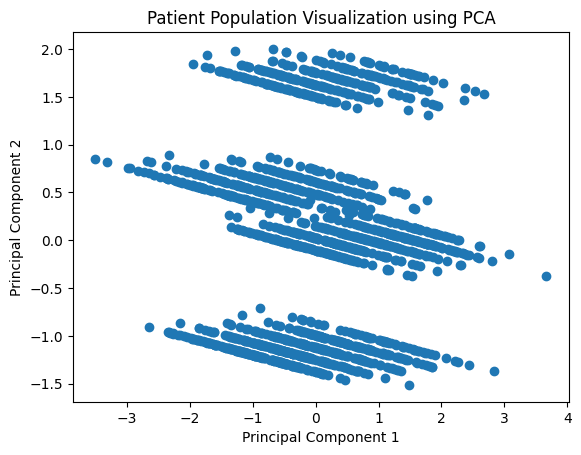

In [34]:
# Create a scatter plot of the PCA results
plt.figure()

plt.scatter(pca_df["PC1"], pca_df["PC2"])

# Label the axes for clarity
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Add a title to the plot
plt.title("Patient Population Visualization using PCA")

# Display the plot
plt.show()

1. Groups of patients

The PCA plot suggests three broad patient groupings or regions in the data. Further clustering analysis would be required to determine whether these represent true clusters. Patients within each group are close together, which suggests they have similar characteristics. These groups may represent different patient subpopulations.

2. Isolated patients

Most patients belong to one of the three groups, but a few points lie farther away from the others. These could be unusual patients, rare cases, or possible outliers that may need further investigation.

3. Overall population spread

The patient population is spread out across the plot, with the clearest separation occurring along Principal Component 2 (PC2). Rather than forming one large group, the data appears to be divided into distinct bands, indicating meaningful differences among patients.

## 4.  t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is a technique that emphasizes local neighborhood structure.
It is often used to highlight clusters that may not be obvious with PCA. It can reveal subtle subgroupings,
but it must be interpreted cautiously.


In [35]:
# Create a t-SNE model to reduce data to two dimensions
tsne = TSNE(n_components=2, random_state=42)

# Fit and transform the scaled data
tsne_components = tsne.fit_transform(scaled_features)

# Convert results into a DataFrame
tsne_df = pd.DataFrame(
    tsne_components,
    columns=["Dim1", "Dim2"]
)

# Display the t-SNE-transformed data
tsne_df

,Dim1,Dim2
0,15.892611,3.300654
1,2.174840,-2.615986
2,16.175838,2.312833
3,-31.251423,-36.686798
4,26.056753,-37.369316
...,...,...
1849,-32.620926,-35.548496
1850,-11.123098,47.154869
1851,24.924088,-30.064426
1852,-10.894042,49.972073


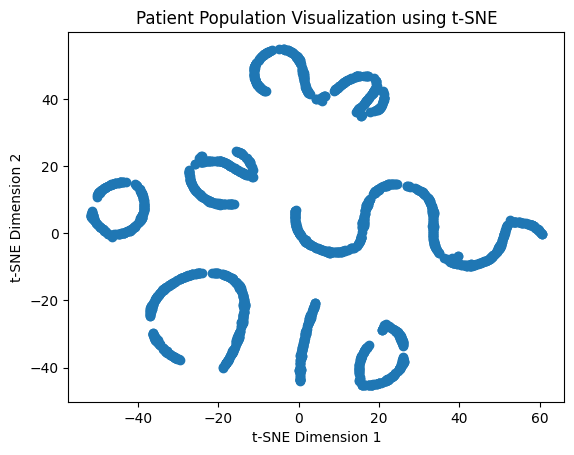

In [36]:
# Create a scatter plot of the t-SNE results
plt.figure()

plt.scatter(tsne_df["Dim1"], tsne_df["Dim2"])

# Label axes
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Add title
plt.title("Patient Population Visualization using t-SNE")

# Display the plot
plt.show()

### Comparison pf PCA vs t-SNE visualization
The PCA plot reveals about three broad patient groups, while the t-SNE plot reveals many smaller, well-separated clusters within the population. This indicates that the dataset likely contains richer subgroup structure than PCA alone shows, making t-SNE more useful for exploring potential patient phenotypes or clinical subpopulations

### Limitations

- PCA captures linear relationships and may not reveal complex nonlinear structures.
- t-SNE is useful for visualization but does not preserve global distances.
- Visual groupings do not necessarily represent clinically meaningful patient populations.
- Additional clustering methods and clinical validation would be needed before drawing conclusions.

###Disclaimer:
This project was completed as part of the coursework for Machine Learning for Healthcare Applications. The dataset used in this analysis is synthetic and de-identified. Additional steps were included to enhance understanding and improve the completeness of the project.